# Model Training with MLflow Tracking
---
## Objectives:
- Apply SMOTE to handle class imbalance
- Train 5 classification models (including baseline)
- Log all experiments to MLflow with unique run names
- Track both technical and business metrics
- Save trained models as MLflow artifacts

## Models to Train:
1. Logistic Regression (Baseline)
2. Random Forest
3. XGBoost
4. LightGBM
5. Gradient Boosting

In [23]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve, fbeta_score, make_scorer
)
import mlflow
import mlflow.sklearn
import xgboost as xgb
import lightgbm as lgb
import joblib
from datetime import datetime

print("Libraries imported successfully!")
print(f"SMOTE version: {__import__('imblearn').__version__}")
print(f"MLflow version: {mlflow.__version__}")

Libraries imported successfully!
SMOTE version: 0.14.1
MLflow version: 3.11.1


### Step 1: Apply SMOTE to Training Data
We apply SMOTE only to the training set to avoid data leakage.

In [ ]:
print("Loading preprocessed data")
X_train = pd.read_csv('../data/interim/scaled/X_train.csv')
X_val = pd.read_csv('../data/interim/scaled/X_val.csv')

Y_train = pd.read_csv('../data/interim/label/Y_train.csv')
Y_val = pd.read_csv('../data/interim/label/Y_val.csv')

X_train.columns = X_train.columns.str.strip()
X_val.columns = X_val.columns.str.strip()


Y_train.columns = Y_train.columns.str.strip()
Y_val.columns = Y_val.columns.str.strip()


print(f"Original training set shape: {X_train.shape}")
print(f"Original class distribution:\n{Y_train['is_fraud'].value_counts(normalize=True)}")

print("\nApplying SMOTE to training data")
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, Y_train_smote = smote.fit_resample(X_train, Y_train['is_fraud'])

if isinstance(Y_train_smote, pd.DataFrame):
    Y_train_smote = Y_train_smote.squeeze()

print(f"After SMOTE training set shape: {X_train_smote.shape}")
print(f"New class distribution:\n{pd.Series(Y_train_smote).value_counts(normalize=True)}")
print("SMOTE applied successfully!")

Loading preprocessed data
Original training set shape: (6999, 16)
Original class distribution:
is_fraud
0    0.984855
1    0.015145
Name: proportion, dtype: float64

Applying SMOTE to training data
After SMOTE training set shape: (13786, 16)
New class distribution:
is_fraud
0    0.5
1    0.5
Name: proportion, dtype: float64
SMOTE applied successfully!


: 

### Step 2: Initialize MLflow Tracking
Set up MLflow experiment with unique run names for each model.

In [ ]:
mlflow.set_tracking_uri("mlruns")
try:
    mlflow.set_experiment("credit_card_fraud_detection")
except Exception as e:
    print(f"Warning: {e}")

print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")
print(f"Active experiment: {mlflow.get_experiment_by_name('credit_card_fraud_detection').name}")
print(f"Experiment ID: {mlflow.get_experiment_by_name('credit_card_fraud_detection').experiment_id}")

MLflow tracking URI: mlruns
Active experiment: credit_card_fraud_detection
Experiment ID: 605197115165042358


: 

### Step 3: Define Business Metrics Function
Calculate business-oriented metrics beyond standard ML metrics.

In [ ]:
def calculate_business_metrics(y_true, y_pred, y_proba=None, cost_fn=150, cost_fp=10, transaction_value=200):
    """
    Calculate business-oriented metrics for fraud detection.
    
    Parameters:
    - y_true: True labels
    - y_pred: Predicted labels
    - y_proba: Predicted probabilities (optional)
    - cost_fn: Cost of false negative (missed fraud) in dollars
    - cost_fp: Cost of false positive (false alarm) in dollars
    - transaction_value: Average transaction value in dollars
    
    Returns:
    - Dictionary of business metrics
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # Financial impact
    total_fraud_amount = fn * transaction_value  # Lost to fraud
    false_alarm_cost = fp * cost_fp  # Cost of investigating false alarms
    total_cost = (fn * cost_fn) + (fp * cost_fp)
    
    # Savings from detection
    detected_fraud = tp * transaction_value
    potential_savings = detected_fraud - false_alarm_cost
    
    business_metrics = {
        'true_positives': int(tp),
        'false_positives': int(fp),
        'true_negatives': int(tn),
        'false_negatives': int(fn),
        'fraud_detection_rate': round(tp / (tp + fn) * 100, 2),  # Recall
        'false_alarm_rate': round(fp / (fp + tn) * 100, 2),
        'total_fraud_missed_amount': int(total_fraud_amount),
        'false_alarm_investigation_cost': int(false_alarm_cost),
        'total_business_cost': int(total_cost),
        'potential_savings': int(potential_savings),
        'roi_percentage': round((potential_savings / total_cost) * 100, 2) if total_cost > 0 else 0
    }
    
    return business_metrics

print("Business metrics function defined successfully!")

Business metrics function defined successfully!


: 

### Step 4: Train Models with MLflow Logging
Train 5 models and log all metrics, parameters, and artifacts to MLflow.

In [ ]:
models_config = {
    'LogisticRegression_Baseline': {
        'model': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
        'params': {'max_iter': 1000, 'random_state': 42, 'class_weight': 'balanced'}
    },
    'RandomForest_v1': {
        'model': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced'),
        'params': {'n_estimators': 100, 'max_depth': 10, 'random_state': 42, 'class_weight': 'balanced'}
    },
    'XGBoost_v1': {
        'model': xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, scale_pos_weight=10),
        'params': {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1, 'random_state': 42, 'scale_pos_weight': 10}
    },
    'LightGBM_v1': {
        'model': lgb.LGBMClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, is_unbalance=True),
        'params': {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1, 'random_state': 42, 'is_unbalance': True}
    },
    'GradientBoosting_v1': {
        'model': GradientBoostingClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42),
        'params': {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1, 'random_state': 42}
    }
}

training_results = []

print("Starting model training with MLflow tracking\n")

for model_name, config in models_config.items():
    print(f"Training: {model_name}\n")
    run_name = f"{model_name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    
    with mlflow.start_run(run_name=run_name):
        model = config['model']
        params = config['params']
        
        print("Training model")
        model.fit(X_train_smote, Y_train_smote)
        
        y_val_pred = model.predict(X_val)
        y_val_proba = model.predict_proba(X_val)[:, 1] if hasattr(model, "predict_proba") else None

        accuracy = accuracy_score(Y_val['is_fraud'], y_val_pred)
        precision = precision_score(Y_val['is_fraud'], y_val_pred)
        recall = recall_score(Y_val['is_fraud'], y_val_pred)
        f1 = f1_score(Y_val['is_fraud'], y_val_pred)
        roc_auc = roc_auc_score(Y_val['is_fraud'], y_val_proba) if y_val_proba is not None else 0
        
        business_metrics = calculate_business_metrics(Y_val['is_fraud'], y_val_pred, y_val_proba)
        
        mlflow.log_params(params)
        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1_score", f1)
        mlflow.log_metric("roc_auc", roc_auc)
        
        mlflow.log_metric("fraud_detection_rate", business_metrics['fraud_detection_rate'])
        mlflow.log_metric("false_alarm_rate", business_metrics['false_alarm_rate'])
        mlflow.log_metric("total_business_cost", business_metrics['total_business_cost'])
        mlflow.log_metric("potential_savings", business_metrics['potential_savings'])
        mlflow.log_metric("roi_percentage", business_metrics['roi_percentage'])
        
        mlflow.sklearn.log_model(model, "model")
        
        result = {
            'model_name': model_name,
            'run_name': run_name,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'roc_auc': roc_auc,
            'fraud_detection_rate': business_metrics['fraud_detection_rate'],
            'false_alarm_rate': business_metrics['false_alarm_rate'],
            'total_business_cost': business_metrics['total_business_cost'],
            'potential_savings': business_metrics['potential_savings'],
            'roi_percentage': business_metrics['roi_percentage'],
            'model_object': model
        }
        training_results.append(result)
        
        print(f"Training complete for {model_name}")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1-Score: {f1:.4f}")
        print(f"ROC-AUC: {roc_auc:.4f}")
        print(f"Fraud Detection Rate: {business_metrics['fraud_detection_rate']:.2f}%")
        print(f"Total Business Cost: ${business_metrics['total_business_cost']:,}")
        print(f"Potential Savings: ${business_metrics['potential_savings']:,}")
        print(f"MLflow Run: {run_name}")


print(f"All {len(models_config)} models trained and logged to MLflow")

Starting model training with MLflow tracking

Training: LogisticRegression_Baseline



2026/05/04 12:33:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Training model


2026/05/04 12:33:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Training complete for LogisticRegression_Baseline
Accuracy: 0.9220
Precision: 0.1533
Recall: 0.9545
F1-Score: 0.2642
ROC-AUC: 0.9860
Fraud Detection Rate: 95.45%
Total Business Cost: $1,310
Potential Savings: $3,040
MLflow Run: LogisticRegression_Baseline_20260504_123346
Training: RandomForest_v1

Training model


...

2026/05/04 12:34:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/04 12:34:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Training complete for LightGBM_v1
Accuracy: 0.9873
Precision: 0.5405
Recall: 0.9091
F1-Score: 0.6780
ROC-AUC: 0.9948
Fraud Detection Rate: 90.91%
Total Business Cost: $470
Potential Savings: $3,830
MLflow Run: LightGBM_v1_20260504_123424
Training: GradientBoosting_v1

Training model


2026/05/04 12:34:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/04 12:34:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Training complete for GradientBoosting_v1
Accuracy: 0.9820
Precision: 0.4359
Recall: 0.7727
F1-Score: 0.5574
ROC-AUC: 0.9910
Fraud Detection Rate: 77.27%
Total Business Cost: $970
Potential Savings: $3,180
MLflow Run: GradientBoosting_v1_20260504_123436
All 5 models trained and logged to MLflow


: 

### Step 5: Visualize Model Comparisons
Create visualizations to compare model performance.

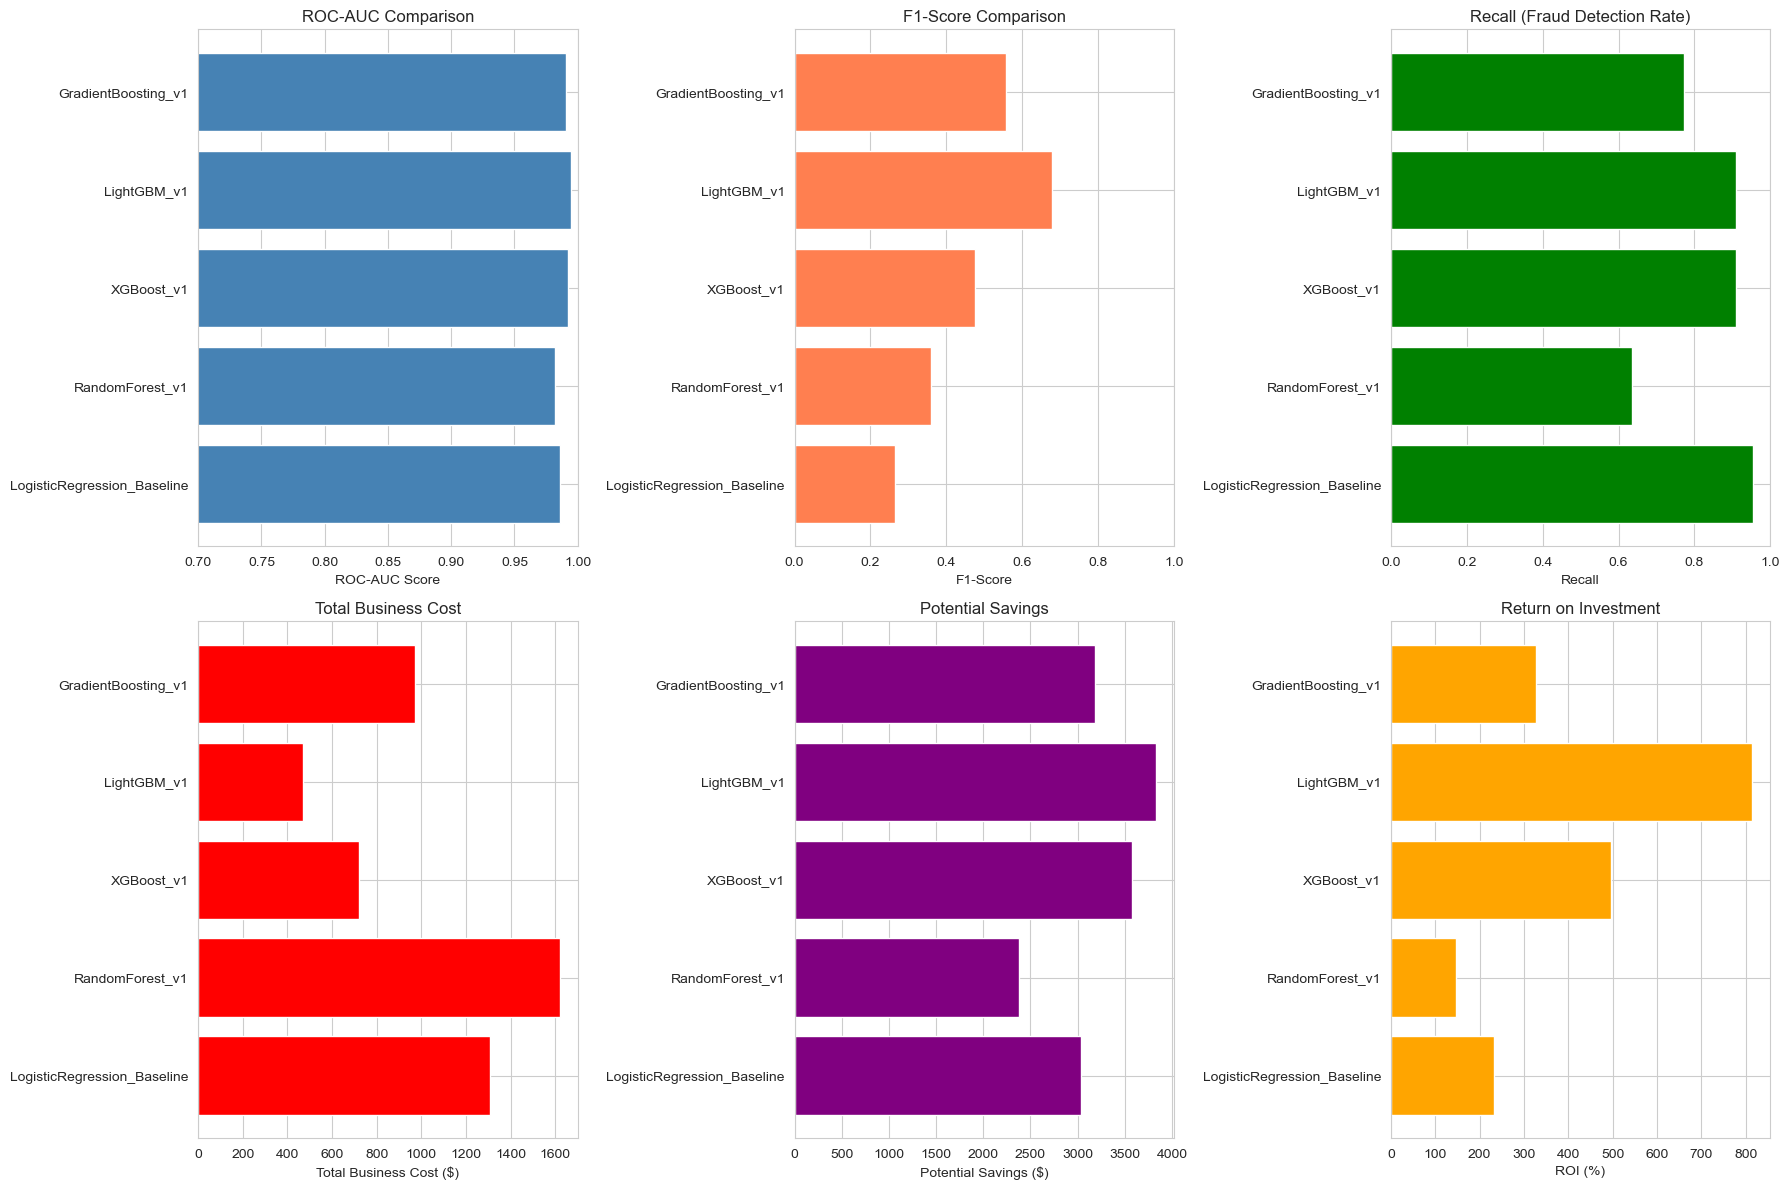

Comparison charts saved as 'model_comparison_charts.png'


: 

In [ ]:
results_df = pd.DataFrame(training_results)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

axes[0, 0].barh(results_df['model_name'], results_df['roc_auc'], color='steelblue')
axes[0, 0].set_xlabel('ROC-AUC Score')
axes[0, 0].set_title('ROC-AUC Comparison')
axes[0, 0].set_xlim([0.7, 1.0])

axes[0, 1].barh(results_df['model_name'], results_df['f1_score'], color='coral')
axes[0, 1].set_xlabel('F1-Score')
axes[0, 1].set_title('F1-Score Comparison')
axes[0, 1].set_xlim([0, 1])

axes[0, 2].barh(results_df['model_name'], results_df['recall'], color='green')
axes[0, 2].set_xlabel('Recall')
axes[0, 2].set_title('Recall (Fraud Detection Rate)')
axes[0, 2].set_xlim([0, 1])

axes[1, 0].barh(results_df['model_name'], results_df['total_business_cost'], color='red')
axes[1, 0].set_xlabel('Total Business Cost ($)')
axes[1, 0].set_title('Total Business Cost')

axes[1, 1].barh(results_df['model_name'], results_df['potential_savings'], color='purple')
axes[1, 1].set_xlabel('Potential Savings ($)')
axes[1, 1].set_title('Potential Savings')

axes[1, 2].barh(results_df['model_name'], results_df['roi_percentage'], color='orange')
axes[1, 2].set_xlabel('ROI (%)')
axes[1, 2].set_title('Return on Investment')

plt.tight_layout()
plt.savefig('model_comparison_charts.png', dpi=300, bbox_inches='tight')
plt.show()

print("Comparison charts saved as 'model_comparison_charts.png'")

In [ ]:
comparison_table = results_df[[
    'model_name', 'accuracy', 'precision', 'recall', 'f1_score', 
    'roc_auc', 'fraud_detection_rate', 'false_alarm_rate',
    'total_business_cost', 'potential_savings', 'roi_percentage'
]].copy()

comparison_table = comparison_table.sort_values('f1_score', ascending=False)

print("MODEL PERFORMANCE COMPARISON TABLE")
print(comparison_table.to_string(index=False))

comparison_table.to_csv('model_comparison_results.csv', index=False)
print("\nComparison table saved as 'model_comparison_results.csv'")

MODEL PERFORMANCE COMPARISON TABLE
                 model_name  accuracy  precision   recall  f1_score  roc_auc  fraud_detection_rate  false_alarm_rate  total_business_cost  potential_savings  roi_percentage
                LightGBM_v1  0.987333   0.540541 0.909091  0.677966 0.994803                 90.91              1.15                  470               3830          814.89
        GradientBoosting_v1  0.982000   0.435897 0.772727  0.557377 0.991020                 77.27              1.49                  970               3180          327.84
                 XGBoost_v1  0.970667   0.322581 0.909091  0.476190 0.992219                 90.91              2.84                  720               3580          497.22
            RandomForest_v1  0.966667   0.250000 0.636364  0.358974 0.982347                 63.64              2.84                 1620               2380          146.91
LogisticRegression_Baseline  0.922000   0.153285 0.954545  0.264151 0.985976                 95.45  

: 

### Step 6: Select Top 3 Models
Based on F1-Score, ROC-AUC, and business metrics, select the top 3 models to move forward.

In [ ]:
results_df['composite_score'] = (
    0.3 * results_df['f1_score'] + 
    0.3 * results_df['roc_auc'] + 
    0.2 * (results_df['recall']) + 
    0.1 * (1 - results_df['false_alarm_rate']/100) +
    0.1 * (results_df['potential_savings'] / results_df['potential_savings'].max())
)

results_df = results_df.sort_values('composite_score', ascending=False)

top_3_models = results_df.head(3)

print("TOP 3 MODELS SELECTED FOR FINAL EVALUATION")
for idx, row in top_3_models.iterrows():
    print(f"\n{idx+1}. {row['model_name']}")
    print(f"Composite Score: {row['composite_score']:.4f}")
    print(f"F1-Score: {row['f1_score']:.4f}")
    print(f"ROC-AUC: {row['roc_auc']:.4f}")
    print(f"Fraud Detection Rate: {row['fraud_detection_rate']:.2f}%")
    print(f"Potential Savings: ${row['potential_savings']:,}")
    print(f"MLflow Run: {row['run_name']}")

top_3_model_names = top_3_models['model_name'].tolist()
with open('top_3_models.txt', 'w') as f:
    for model_name in top_3_model_names:
        f.write(f"{model_name}\n")

print("Top 3 model names saved to 'top_3_models.txt'")
print(f"Models to advance: {', '.join(top_3_model_names)}")

TOP 3 MODELS SELECTED FOR FINAL EVALUATION

4. LightGBM_v1
Composite Score: 0.8825
F1-Score: 0.6780
ROC-AUC: 0.9948
Fraud Detection Rate: 90.91%
Potential Savings: $3,830
MLflow Run: LightGBM_v1_20260504_123424

3. XGBoost_v1
Composite Score: 0.8130
F1-Score: 0.4762
ROC-AUC: 0.9922
Fraud Detection Rate: 90.91%
Potential Savings: $3,580
MLflow Run: XGBoost_v1_20260504_123414

5. GradientBoosting_v1
Composite Score: 0.8006
F1-Score: 0.5574
ROC-AUC: 0.9910
Fraud Detection Rate: 77.27%
Potential Savings: $3,180
MLflow Run: GradientBoosting_v1_20260504_123436
Top 3 model names saved to 'top_3_models.txt'
Models to advance: LightGBM_v1, XGBoost_v1, GradientBoosting_v1


: 

### Summary of Training Process
- Applied SMOTE to training data  
- Trained 5 models with unique MLflow run names  
- Logged all metrics (technical + business) to MLflow  
- Saved models as MLflow artifacts  
- Generated comparison visualizations  
- Selected top 3 models for tuning



### Step 7: Hyperparameter Tuning for Top 3 Models

In this section, we'll optimize the hyperparameters of our top 3 baseline performers:
- **LightGBM** 
- **XGBoost** 
- **GradientBoosting** 

We'll use **RandomizedSearchCV** with 30 iterations per model to balance thoroughness and computational efficiency.

In [ ]:
# Import tuning libraries
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform, loguniform
import time

print("Libraries for hyperparameter tuning imported successfully!")

Libraries for hyperparameter tuning imported successfully!


: 

#### Define Hyperparameter Search Spaces

We'll tune the most impactful hyperparameters for each model:
- **Tree depth/complexity**: Controls model capacity and overfitting
- **Learning rate**: Step size for gradient updates
- **Regularization**: Prevents overfitting (alpha, lambda)
- **Subsampling**: Adds randomness for better generalization

In [ ]:
param_distributions = {
    'LightGBM': {
        'n_estimators': randint(100, 500),
        'max_depth': randint(4, 15),
        'learning_rate': uniform(0.01, 0.3),
        'num_leaves': randint(20, 100),
        'min_child_samples': randint(10, 100),
        'subsample': uniform(0.7, 0.3),
        'colsample_bytree': uniform(0.7, 0.3),
        'reg_alpha': loguniform(0.001, 1.0),
        'reg_lambda': loguniform(0.001, 1.0)
    },
    'XGBoost': {
        'n_estimators': randint(100, 500),
        'max_depth': randint(4, 12),
        'learning_rate': uniform(0.01, 0.3),
        'min_child_weight': randint(1, 10),
        'subsample': uniform(0.7, 0.3),
        'colsample_bytree': uniform(0.7, 0.3),
        'gamma': uniform(0, 1),
        'reg_alpha': loguniform(0.001, 1.0),
        'reg_lambda': loguniform(0.001, 1.0)
    },
    'GradientBoosting': {
        'n_estimators': randint(100, 500),
        'max_depth': randint(3, 10),
        'learning_rate': uniform(0.01, 0.3),
        'min_samples_split': randint(2, 20),
        'min_samples_leaf': randint(1, 20),
        'subsample': uniform(0.7, 0.3),
        'max_features': ['sqrt', 'log2']
    }
}

print("Hyperparameter search spaces defined!")
for model_name, params in param_distributions.items():
    print(f"\n{model_name}:")
    print(f"  {len(params)} hyperparameters to tune")

Hyperparameter search spaces defined!

LightGBM:
  9 hyperparameters to tune

XGBoost:
  9 hyperparameters to tune

GradientBoosting:
  7 hyperparameters to tune


: 

#### Tuning Function with MLflow Integration

This function will:
1. Run RandomizedSearchCV with cross-validation
2. Log all hyperparameters and metrics to MLflow
3. Save the best model as an artifact
4. Return comprehensive results for comparison

In [ ]:
def tune_model(model_name, base_model, param_dist, X_train, y_train, X_val, y_val, 
               n_iter=30, cv=3, random_state=42):
    """
    Tune hyperparameters using RandomizedSearchCV and log to MLflow.
    
    Parameters:
    -----------
    model_name : str
        Name of the model for logging
    base_model : sklearn estimator
        Base model to tune
    param_dist : dict
        Hyperparameter search space
    X_train, y_train : Training data (with SMOTE applied)
    X_val, y_val : Validation data (unscaled)
    n_iter : int
        Number of parameter settings sampled
    cv : int
        Cross-validation folds
    random_state : int
        Random seed for reproducibility
    
    Returns:
    --------
    dict : Tuning results with metrics and best model
    """
    print(f"Tuning {model_name}...")
    
    tuning_run_name = f"{model_name}_tuning_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    
    with mlflow.start_run(run_name=tuning_run_name):
        print(f"Setting up RandomizedSearchCV with {n_iter} iterations...")
        
        search = RandomizedSearchCV(
            estimator=base_model,
            param_distributions=param_dist,
            n_iter=n_iter,
            scoring='f1',  # Optimize for F1-score
            cv=cv,
            random_state=random_state,
            n_jobs=-1,
            verbose=1,
            return_train_score=True
        )
        
        print("Starting hyperparameter search...")
        start_time = time.time()
        search.fit(X_train, y_train)
        elapsed_time = time.time() - start_time
        
        print(f"\nTuning completed in {elapsed_time:.2f} seconds")
        print(f"Best F1-Score (CV): {search.best_score_:.4f}")
        print(f"Best Parameters:")
        for param, value in search.best_params_.items():
            print(f"{param}: {value}")
        
        best_model = search.best_estimator_
        y_val_pred = best_model.predict(X_val)
        y_val_proba = best_model.predict_proba(X_val)[:, 1]
        
        val_accuracy = accuracy_score(y_val, y_val_pred)
        val_precision = precision_score(y_val, y_val_pred)
        val_recall = recall_score(y_val, y_val_pred)
        val_f1 = f1_score(y_val, y_val_pred)
        val_roc_auc = roc_auc_score(y_val, y_val_proba)
        
        val_business_metrics = calculate_business_metrics(y_val, y_val_pred, y_val_proba)
        
        mlflow.log_params(search.best_params_)
        mlflow.log_param("n_iter", n_iter)
        mlflow.log_param("cv", cv)
        mlflow.log_param("tuning_time_seconds", round(elapsed_time, 2))
        
        mlflow.log_metric("val_accuracy", val_accuracy)
        mlflow.log_metric("val_precision", val_precision)
        mlflow.log_metric("val_recall", val_recall)
        mlflow.log_metric("val_f1_score", val_f1)
        mlflow.log_metric("val_roc_auc", val_roc_auc)
        
        mlflow.log_metric("val_fraud_detection_rate", val_business_metrics['fraud_detection_rate'])
        mlflow.log_metric("val_false_alarm_rate", val_business_metrics['false_alarm_rate'])
        mlflow.log_metric("val_total_business_cost", val_business_metrics['total_business_cost'])
        mlflow.log_metric("val_potential_savings", val_business_metrics['potential_savings'])
        mlflow.log_metric("val_roi_percentage", val_business_metrics['roi_percentage'])
        
        mlflow.sklearn.log_model(best_model, "tuned_model")
        
        tuning_result = {
            'model_name': f"{model_name}_Tuned",
            'base_model_name': model_name,
            'best_params': search.best_params_,
            'best_cv_score': search.best_score_,
            'val_accuracy': val_accuracy,
            'val_precision': val_precision,
            'val_recall': val_recall,
            'val_f1_score': val_f1,
            'val_roc_auc': val_roc_auc,
            'val_fraud_detection_rate': val_business_metrics['fraud_detection_rate'],
            'val_false_alarm_rate': val_business_metrics['false_alarm_rate'],
            'val_total_business_cost': val_business_metrics['total_business_cost'],
            'val_potential_savings': val_business_metrics['potential_savings'],
            'val_roi_percentage': val_business_metrics['roi_percentage'],
            'tuning_time': elapsed_time,
            'model_object': best_model
        }
        
        print(f"\nValidation Performance:")
        print(f"F1-Score: {val_f1:.4f}")
        print(f"ROC-AUC: {val_roc_auc:.4f}")
        print(f"Fraud Detection Rate: {val_business_metrics['fraud_detection_rate']:.2f}%")
        print(f"ROI: {val_business_metrics['roi_percentage']:.2f}%")
        print(f"MLflow Run: {tuning_run_name}")
        
        return tuning_result

: 

#### Execute Hyperparameter Tuning

Now we'll tune all 3 models sequentially. This will take approximately 10-15 minutes total (3-5 min per model).

**Note**: We use the SMOTE-augmented training data (`X_train_smote`, `Y_train_smote`) for tuning, and evaluate on the original validation set (`X_val`, `Y_val`).

In [ ]:
top_3_baseline = ['LightGBM_v1', 'XGBoost_v1', 'GradientBoosting_v1']

print(f"Tuning top 3 baseline models: {', '.join(top_3_baseline)}")

X_train_tune = X_train_smote
y_train_tune = Y_train_smote

tuned_results = []

print("\nTuning LightGBM")
lightgbm_base = lgb.LGBMClassifier(random_state=42, is_unbalance=True)
lightgbm_result = tune_model(
    model_name='LightGBM',
    base_model=lightgbm_base,
    param_dist=param_distributions['LightGBM'],
    X_train=X_train_tune,
    y_train=y_train_tune,
    X_val=X_val,
    y_val=Y_val['is_fraud'],
    n_iter=30,
    cv=3
)
tuned_results.append(lightgbm_result)

print("\nTuning XGBoost")
xgb_base = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_result = tune_model(
    model_name='XGBoost',
    base_model=xgb_base,
    param_dist=param_distributions['XGBoost'],
    X_train=X_train_tune,
    y_train=y_train_tune,
    X_val=X_val,
    y_val=Y_val['is_fraud'],
    n_iter=30,
    cv=3
)
tuned_results.append(xgb_result)

print("\nTuning GradientBoosting")
gb_base = GradientBoostingClassifier(random_state=42)
gb_result = tune_model(
    model_name='GradientBoosting',
    base_model=gb_base,
    param_dist=param_distributions['GradientBoosting'],
    X_train=X_train_tune,
    y_train=y_train_tune,
    X_val=X_val,
    y_val=Y_val['is_fraud'],
    n_iter=30,
    cv=3
)
tuned_results.append(gb_result)

print("All 3 models tuned successfully!")

Tuning top 3 baseline models: LightGBM_v1, XGBoost_v1, GradientBoosting_v1

Tuning LightGBM
Tuning LightGBM...
Setting up RandomizedSearchCV with 30 iterations...
Starting hyperparameter search...
Fitting 3 folds for each of 30 candidates, totalling 90 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 6893, number of negative: 6893
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001520 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1801
[LightGBM] [Info] Number of data points in the train set: 13786, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] 

2026/05/04 12:45:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/04 12:45:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Validation Performance:
F1-Score: 0.7500
ROC-AUC: 0.9975
Fraud Detection Rate: 81.82%
ROI: 517.65%
MLflow Run: LightGBM_tuning_20260504_124440

Tuning XGBoost
Tuning XGBoost...
Setting up RandomizedSearchCV with 30 iterations...
Starting hyperparameter search...
Fitting 3 folds for each of 30 candidates, totalling 90 fits

Tuning completed in 25.83 seconds
Best F1-Score (CV): 0.9952
Best Parameters:
colsample_bytree: 0.8001125833417065
gamma: 0.14286681792194078
learning_rate: 0.20526654188465587
max_depth: 8
min_child_weight: 2
n_estimators: 443
reg_alpha: 0.31428808908401085
reg_lambda: 0.004335281794951566
subsample: 0.7545474901621302


2026/05/04 12:46:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/04 12:46:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Validation Performance:
F1-Score: 0.6792
ROC-AUC: 0.9956
Fraud Detection Rate: 81.82%
ROI: 475.34%
MLflow Run: XGBoost_tuning_20260504_124556

Tuning GradientBoosting
Tuning GradientBoosting...
Setting up RandomizedSearchCV with 30 iterations...
Starting hyperparameter search...
Fitting 3 folds for each of 30 candidates, totalling 90 fits

Tuning completed in 166.95 seconds
Best F1-Score (CV): 0.9975
Best Parameters:
learning_rate: 0.17838315927084888
max_depth: 9
max_features: log2
min_samples_leaf: 7
min_samples_split: 10
n_estimators: 306
subsample: 0.8282623055075649


2026/05/04 12:49:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/04 12:49:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Validation Performance:
F1-Score: 0.5500
ROC-AUC: 0.9922
Fraud Detection Rate: 50.00%
ROI: 123.84%
MLflow Run: GradientBoosting_tuning_20260504_124634
All 3 models tuned successfully!


: 

#### Final Model Selection (After Tuning)

Now we'll combine **all 8 models** (5 baseline + 3 tuned) and select the **final top 3** based on composite score. This ensures we're choosing the absolute best performers for test evaluation.

In [25]:
print("FINAL MODEL SELECTION (Baseline + Tuned)")

all_models_results = results_df.copy()

for tuned_result in tuned_results:
    all_models_results = pd.concat([
        all_models_results,
        pd.DataFrame([{
            'model_name': tuned_result['model_name'],
            'run_name': f"{tuned_result['model_name']}_{datetime.now().strftime('%Y%m%d_%H%M%S')}",
            'accuracy': tuned_result['val_accuracy'],
            'precision': tuned_result['val_precision'],
            'recall': tuned_result['val_recall'],
            'f1_score': tuned_result['val_f1_score'],
            'roc_auc': tuned_result['val_roc_auc'],
            'fraud_detection_rate': tuned_result['val_fraud_detection_rate'],
            'false_alarm_rate': tuned_result['val_false_alarm_rate'],
            'total_business_cost': tuned_result['val_total_business_cost'],
            'potential_savings': tuned_result['val_potential_savings'],
            'roi_percentage': tuned_result['val_roi_percentage'],
            'model_object': tuned_result['model_object']
        }])
    ], ignore_index=True)

all_models_results['composite_score'] = (
    0.3 * all_models_results['f1_score'] + 
    0.3 * all_models_results['roc_auc'] + 
    0.2 * all_models_results['recall'] + 
    0.1 * (1 - all_models_results['false_alarm_rate']/100) +
    0.1 * (all_models_results['potential_savings'] / all_models_results['potential_savings'].max())
)

all_models_results = all_models_results.sort_values('composite_score', ascending=False)
final_top_3 = all_models_results.head(3)

print("TOP 3 MODELS ADVANCING TO TEST EVALUATION")
for idx, row in final_top_3.iterrows():
    print(f"\n{idx+1}. {row['model_name']}")
    print(f"Composite Score: {row['composite_score']:.4f}")
    print(f"F1-Score: {row['f1_score']:.4f} | ROC-AUC: {row['roc_auc']:.4f}")
    print(f"Fraud Detection Rate: {row['fraud_detection_rate']:.2f}%")
    print(f"False Alarm Rate: {row['false_alarm_rate']:.2f}%")
    print(f"ROI: ${row['roi_percentage']:.2f}%")

final_top_3_names = final_top_3['model_name'].tolist()
with open('../outputs/model_selection//text/final_top_3_models.txt', 'w') as f:
    for name in final_top_3_names:
        f.write(f"{name}\n")

all_models_results.to_csv('../outputs/model_selection/csv/all_models_comparison_final.csv', index=False)
                
print(f"Final top 3 saved to '../outputs/model_selection/text/final_top_3_models.txt'")
print(f"Full comparison saved to '../outputs/model_selection/csv/all_models_comparison_final.csv'")
print(f"Models advancing: {', '.join(final_top_3_names)}")

FINAL MODEL SELECTION (Baseline + Tuned)
TOP 3 MODELS ADVANCING TO TEST EVALUATION

1. LightGBM_v1
Composite Score: 0.8825
F1-Score: 0.6780 | ROC-AUC: 0.9948
Fraud Detection Rate: 90.91%
False Alarm Rate: 1.15%
ROI: $814.89%

6. LightGBM_Tuned
Composite Score: 0.8793
F1-Score: 0.7500 | ROC-AUC: 0.9975
Fraud Detection Rate: 81.82%
False Alarm Rate: 0.54%
ROI: $517.65%

7. XGBoost_Tuned
Composite Score: 0.8558
F1-Score: 0.6792 | ROC-AUC: 0.9956
Fraud Detection Rate: 81.82%
False Alarm Rate: 0.88%
ROI: $475.34%
Final top 3 saved to '../outputs/model_selection/text/final_top_3_models.txt'
Full comparison saved to '../outputs/model_selection/csv/all_models_comparison_final.csv'
Models advancing: LightGBM_v1, LightGBM_Tuned, XGBoost_Tuned


In [24]:
print("SUMMARY")
print("Applied SMOTE to training data")
print("Trained 5 baseline models")
print("Logged all experiments to MLflow")
print("Tuned top 3 baseline models (LightGBM, XGBoost, GradientBoosting)")
print("Compared baseline vs tuned performance")
print("Selected final top 3 models from 8 total candidates")
print("Saved models as MLflow artifacts")
print(f"\nTotal models evaluated: {len(all_models_results)}")
print(f"Best model: {final_top_3.iloc[0]['model_name']}")
print(f"Best F1-Score: {final_top_3.iloc[0]['f1_score']:.4f}")
print(f"Best ROI: ${final_top_3.iloc[0]['roi_percentage']:.2f}%")

SUMMARY
Applied SMOTE to training data
Trained 5 baseline models
Logged all experiments to MLflow
Tuned top 3 baseline models (LightGBM, XGBoost, GradientBoosting)
Compared baseline vs tuned performance
Selected final top 3 models from 8 total candidates
Saved models as MLflow artifacts

Total models evaluated: 8
Best model: LightGBM_v1
Best F1-Score: 0.6780
Best ROI: $814.89%


### Summary of Tuning Process

- Applied SMOTE to training data (handled class imbalance)
- Trained 5 baseline models (Logistic Regression, RF, XGBoost, LightGBM, GBM)
- Logged all experiments to MLflow with unique run names
- Tracked both technical and business metrics
- Saved all models as MLflow artifacts
- Performed hyperparameter tuning on top 3 baseline models
- Compared baseline vs tuned performance
- Selected final top 3 models from 8 total candidates

**Total Models Evaluated:** 8 (5 baseline + 3 tuned)